# ClosetAI · Previsione degli utilizzi nei prossimi 90 giorni
## Random forest per una regressione non lineare

**Stato nel prodotto:** esperimento di ricerca, non collegato alla
UI. Il prodotto mostra conteggi e cost-per-wear osservati; non espone
ancora una previsione futura.

In [1]:
# Trova la radice del repository anche se Jupyter parte da una sottocartella.
from pathlib import Path

def find_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "backend" / "pyproject.toml").is_file() and (candidate / "ml").is_dir():
            return candidate
    raise FileNotFoundError("Radice di ClosetAI non trovata")

ROOT = find_project_root()
SEED = 42
print(f"Repository: {ROOT}")

Repository: C:\devel\closet-ai


In [2]:
# Dataset sintetico deterministico usato SOLO per l'esperimento didattico.
# In produzione queste righe dovrebbero arrivare dal wear log consensuale.
import numpy as np
import pandas as pd

CATEGORIES = ["t-shirt", "camicia", "felpa", "maglione", "giacca", "cappotto",
              "jeans", "pantaloni", "shorts", "gonna", "vestito", "scarpe"]
COLORS = ["nero", "bianco", "blu", "rosso", "verde", "beige", "grigio", "marrone"]
WEAR_PRIOR = {"t-shirt": 38, "camicia": 20, "felpa": 24, "maglione": 18,
              "giacca": 12, "cappotto": 8, "jeans": 34, "pantaloni": 24,
              "shorts": 12, "gonna": 10, "vestito": 8, "scarpe": 30}
PRICE_RANGE = {"t-shirt": (10, 40), "camicia": (25, 90), "felpa": (25, 80),
               "maglione": (40, 130), "giacca": (60, 220), "cappotto": (120, 400),
               "jeans": (40, 140), "pantaloni": (30, 120), "shorts": (15, 60),
               "gonna": (25, 100), "vestito": (45, 180), "scarpe": (50, 180)}

def generate_wardrobe(n=800, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    for _ in range(n):
        category = str(rng.choice(CATEGORIES))
        low, high = PRICE_RANGE[category]
        price = float(rng.uniform(low, high))
        days_owned = int(rng.integers(20, 1100))
        month = int(rng.integers(0, 12))
        years = days_owned / 365
        price_factor = 1 - 0.1 * (price - low) / max(high - low, 1)
        # Outcome didattico a 90 giorni. Questi coefficienti non sono
        # osservazioni reali: sono dichiarati per rendere l'esperimento
        # riproducibile senza creare un dataset degenere.
        occasion_risk = {"cappotto": 1.55, "vestito": 1.25, "giacca": .85,
                         "gonna": .65, "camicia": .45}.get(category, 0.0)
        off_season = (
            1.35 if category in {"cappotto", "maglione", "giacca"} and month in {4, 5, 6, 7, 8}
            else .9 if category in {"shorts", "t-shirt"} and month in {10, 11, 0, 1, 2}
            else 0.0
        )
        price_risk = .55 * ((price - low) / max(high - low, 1))
        logit = -2.25 + occasion_risk + off_season + price_risk + rng.normal(0, .20)
        ghost_probability = 1 / (1 + np.exp(-logit))
        ghost_outcome = int(rng.random() < ghost_probability)

        if ghost_outcome:
            wear = int(rng.integers(0, 2))
        else:
            wear = WEAR_PRIOR[category] * years * price_factor * rng.normal(1, 0.25)
        rows.append({
            "category": category, "color": str(rng.choice(COLORS)),
            "price_eur": round(price, 2), "days_owned": days_owned,
            "purchase_month": month, "wear_count": max(0, int(round(wear))),
            "is_ghost": ghost_outcome,
        })
    data = pd.DataFrame(rows)
    return data

df = generate_wardrobe()
print(df.shape, "ghost rate", f"{df['is_ghost'].mean():.1%}")
df.head()

(800, 7) ghost rate 24.2%


,category,color,price_eur,days_owned,purchase_month,wear_count,is_ghost
0,camicia,verde,53.53,855,5,1,1
1,scarpe,bianco,148.95,794,9,74,0
2,scarpe,marrone,133.70,454,9,38,0
3,t-shirt,rosso,34.83,318,7,40,0
4,vestito,bianco,150.08,840,2,1,1


MAE: 0.75 utilizzi · R²: 0.893


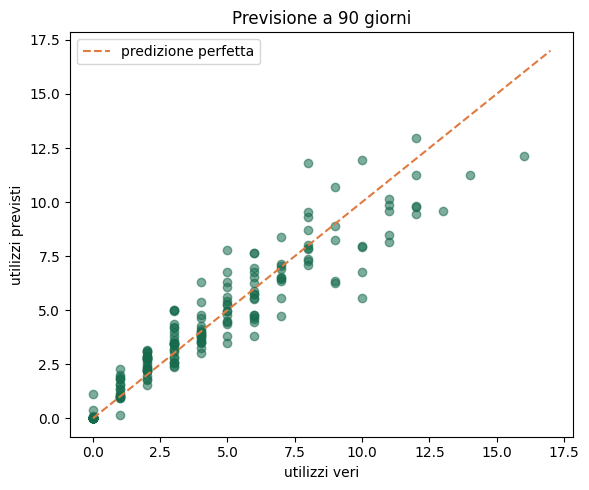

In [3]:
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

rng = np.random.default_rng(SEED)
season = np.sin((df["purchase_month"] / 12) * 2 * np.pi) * 0.3 + 1
df["wear_next_90d"] = (
    (df["wear_count"] / np.maximum(df["days_owned"] / 365, 0.3)) / 4
    * season * rng.normal(1, 0.15, len(df))
).clip(0).round().astype(int)

cat = ["category", "color"]
num = ["price_eur", "days_owned", "purchase_month", "wear_count"]
X_train, X_test, y_train, y_test = train_test_split(
    df[cat + num], df["wear_next_90d"], test_size=0.25, random_state=SEED
)
model = Pipeline([
    ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat), ("num", "passthrough", num)])),
    ("model", RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=SEED, n_jobs=-1)),
])
model.fit(X_train, y_train)
prediction = model.predict(X_test)
mae = mean_absolute_error(y_test, prediction)
r2 = r2_score(y_test, prediction)
print(f"MAE: {mae:.2f} utilizzi · R²: {r2:.3f}")

limit = max(float(y_test.max()), float(prediction.max())) + 1
plt.figure(figsize=(6, 5))
plt.scatter(y_test, prediction, alpha=.55, color="#176B4D")
plt.plot([0, limit], [0, limit], "--", color="#E07A3F", label="predizione perfetta")
plt.xlabel("utilizzi veri"); plt.ylabel("utilizzi previsti")
plt.title("Previsione a 90 giorni"); plt.legend(); plt.tight_layout(); plt.show()

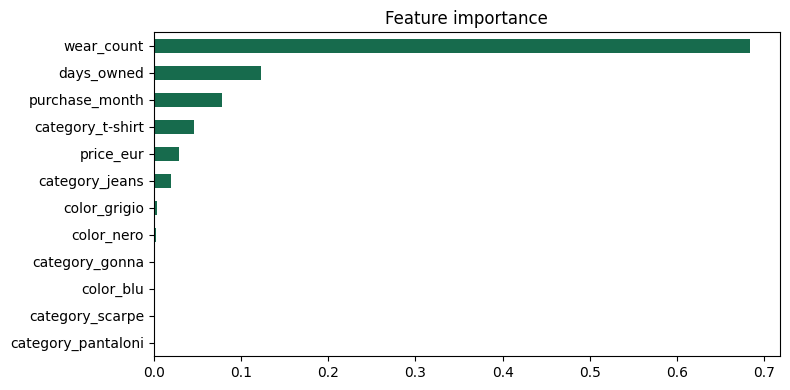

In [4]:
# Importanza impurity-based: utile per orientarsi, non è causalità.
cat_names = model.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(cat)
feature_names = list(cat_names) + num
importance = pd.Series(model.named_steps["model"].feature_importances_, index=feature_names).nlargest(12)
importance.sort_values().plot.barh(figsize=(8, 4), color="#176B4D", title="Feature importance")
plt.tight_layout(); plt.show()

### Cosa dire all'esame

- MAE è espresso nell'unità comprensibile: numero di utilizzi.
- R² confronta il modello con la media, ma può essere instabile su
  dataset piccoli o distribuzioni diverse.
- Il wear storico è un segnale legittimo perché esiste prima della
  finestra futura; bisogna però costruire finestre temporali reali
  per evitare leakage.
- L'importanza di una feature non implica una relazione causale.